In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
df=pd.read_csv("/content/nlp_dataset.csv")
df

,Text
0,Natural Language Processing is a fascinating f...
1,It bridges the gap between humans and machines...
2,NLP techniques are widely used in applications...
3,Machine translation and speech recognition are...
4,"Despite its advancements, NLP faces challenges..."
5,Continuous research and innovation are improvi...
6,"The potential of NLP is vast, making it essent..."


In [ ]:
#dowload required nltk resorces
nltk.download('punkt')# tokenizer
nltk.download('stopwords')#stopwords
nltk.download('wordnet')#wordnet for lemmetization
nltk.download('omw-1.4')#lemmatization data
nltk.download('punkt_tab')#dowload the punkt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
#initialize stopwords and lemmatizer
stop_words=set(stopwords.words('english'))
print(stop_words)
lemmatizer=WordNetLemmatizer()

{'has', "haven't", "that'll", 'theirs', 'more', "i've", 'were', 'before', 'weren', 'his', 'me', "didn't", "wasn't", "they're", 'all', 'shouldn', 'did', 'we', 've', "i'll", 'd', 'won', 'no', 'or', 'hadn', 'her', 'have', 'hasn', 'there', 'had', 'from', "you've", 'against', 'do', 'wasn', 'yours', 'mightn', 'they', 'y', "we'd", "it's", 'so', 'nor', 'other', 'don', "you're", 'why', "you'll", 'but', 'needn', 'which', "isn't", "won't", 'its', 'then', 'when', 'it', 'myself', 'into', "she'd", "we'll", 'too', 'ma', 'am', 'mustn', 'most', 'ain', 'and', 'by', 'up', 'o', "he'd", 'if', "shan't", 'can', 'only', 'haven', 'with', 'i', 'll', 'aren', 'below', 'same', 'through', "they'd", 'above', 'here', 'you', 'to', 'than', 'over', 'what', 'further', 'shan', "he's", "weren't", 'been', "she'll", "it'd", 'just', "should've", 'once', 'himself', "needn't", 'didn', 'under', 'themselves', 'wouldn', 'each', 'hers', 'he', "he'll", "it'll", "mightn't", 'of', "wouldn't", 'does', 'those', 'until', 'own', 'was', 'o

In [ ]:
def process_text(text):
  #tokenization
  words=word_tokenize(text)
  #stopward removal
  filtered_tokens=[word for word in words if word.lower() not in stop_words]
  #lemmatization
  lemmatized_tokens=[lemmatizer.lemmatize(word.lower()) for word in filtered_tokens]
  return{
      "Original_Tokens":text,
      "Tokenized_Tokens":words,
      "Filtered_Tokens":filtered_tokens,
      "Lemmatized_Tokens":lemmatized_tokens
  }

#apply processing on each row of the dataset
results = df['Text'].apply(process_text)

#convert results to a dataframe
processed_df = pd.DataFrame(results.tolist())

#display processed DataFrame
print(processed_df.head())

#Save processed results to a new CSV file
processed_file_path ="processed_nlp_dataset.csv"
processed_df.to_csv(processed_file_path,index=False)
print(f"Processed results saved to {processed_file_path}")

                                     Original_Tokens  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   

                                    Tokenized_Tokens  \
0  [Natural, Language, Processing, is, a, fascina...   
1  [It, bridges, the, gap, between, humans, and, ...   
2  [NLP, techniques, are, widely, used, in, appli...   
3  [Machine, translation, and, speech, recognitio...   
4  [Despite, its, advancements, ,, NLP, faces, ch...   

                                     Filtered_Tokens  \
0  [Natural, Language, Processing, fascinating, f...   
1  [bridges, gap, humans, machines, enabling, com...   
2  [NLP, techniques, widely, used, applications, ...   
3  [Machine, translation, speech, recognition, co...   
4  [Despite, advancements, ,, NLP, faces, chal

In [ ]:
df


,Text
0,Natural Language Processing is a fascinating f...
1,It bridges the gap between humans and machines...
2,NLP techniques are widely used in applications...
3,Machine translation and speech recognition are...
4,"Despite its advancements, NLP faces challenges..."
5,Continuous research and innovation are improvi...
6,"The potential of NLP is vast, making it essent..."


In [ ]:
results


,Text
0,{'Original_Tokens': 'Natural Language Processi...
1,{'Original_Tokens': 'It bridges the gap betwee...
2,{'Original_Tokens': 'NLP techniques are widely...
3,{'Original_Tokens': 'Machine translation and s...
4,"{'Original_Tokens': 'Despite its advancements,..."
5,{'Original_Tokens': 'Continuous research and i...
6,{'Original_Tokens': 'The potential of NLP is v...


VECTORIZATION

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [ ]:
text_data=[
    "Natural Language Processing is a fascinating field of Artificial Intelligence.",
    "It bridges the gap between humans and machines by enabling computers to understand human language.",
    "NLP techniques are widely used in applications such as chatbots and sentiment analysis.",
    "Machine translation and speech recognition are common use cases of NLP.",
    "Despite its advancements, NLP faces challenges including ambiguity in language.",
    "Continuous research and innovation are improving NLP rapidly.",
    "The potential of NLP is vast, making it essential in modern technology."
    ]

In [ ]:
#initialize CountVectorizer
vectorizer = CountVectorizer()

In [ ]:
#fit and transform the text data
bow_matrix = vectorizer.fit_transform(text_data)

In [ ]:
#convert the bow matrix to a dataframe
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())

In [ ]:
#display the bag of words representation
print("Bag of Words Representation:")
print(bow_df)

Bag of Words Representation:
   advancements  ambiguity  analysis  and  applications  are  artificial  as  \
0             0          0         0    0             0    0           1   0   
1             0          0         0    1             0    0           0   0   
2             0          0         1    1             1    1           0   1   
3             0          0         0    1             0    1           0   0   
4             1          1         0    0             0    0           0   0   
5             0          0         0    1             0    1           0   0   
6             0          0         0    0             0    0           0   0   

   between  bridges  ...  techniques  technology  the  to  translation  \
0        0        0  ...           0           0    0   0            0   
1        1        1  ...           0           0    1   1            0   
2        0        0  ...           1           0    0   0            0   
3        0        0  ...          

In [ ]:
#save to csv(optional)
bow_df.to_csv("bag_of words.csv", index=False)
print("\nBag of Words saved as 'bag_of_words.csv'.")


Bag of Words saved as 'bag_of_words.csv'.


In [ ]:
bow_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 78 stored elements and shape (7, 60)>

In [ ]:
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

In [ ]:
#dowload necessary resources
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
#intialize lemmatizer and stemmer
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

In [ ]:
#define functions for lemmatization and stemming
def lemmatize_text(Text):
  tokens = word_tokenize(str(Text))
  return ' '.join([stemmer.stem(word)for word in tokens])
def stem_text(Text):
  tokens = word_tokenize(str(Text))
  return ' '.join([stemmer.stem(word)for word in tokens])
#apply lemmatization and stemming
df['lemmatized_text'] = df['Text'].apply(lemmatize_text)
df['stemmed_text'] = df['Text'].apply(stem_text)


In [ ]:
#save the comparison dataset
output_path = "lemmatized_vs_stemmed.csv"
df.to_csv(output_path, index=False)
#preview the comparison
print(df[['Text', 'lemmatized_text', 'stemmed_text']])
print(f"Comaprison dataset saved to  {output_path}")

                                                Text  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   
5  Continuous research and innovation are improvi...   
6  The potential of NLP is vast, making it essent...   

                                     lemmatized_text  \
0  natur languag process is a fascin field of art...   
1  it bridg the gap between human and machin by e...   
2  nlp techniqu are wide use in applic such as ch...   
3  machin translat and speech recognit are common...   
4  despit it advanc , nlp face challeng includ am...   
5  continu research and innov are improv nlp rapi...   
6  the potenti of nlp is vast , make it essenti i...   

                                        stemmed_text  
0  natur languag process is a fascin field of a

WORD CLOUD

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

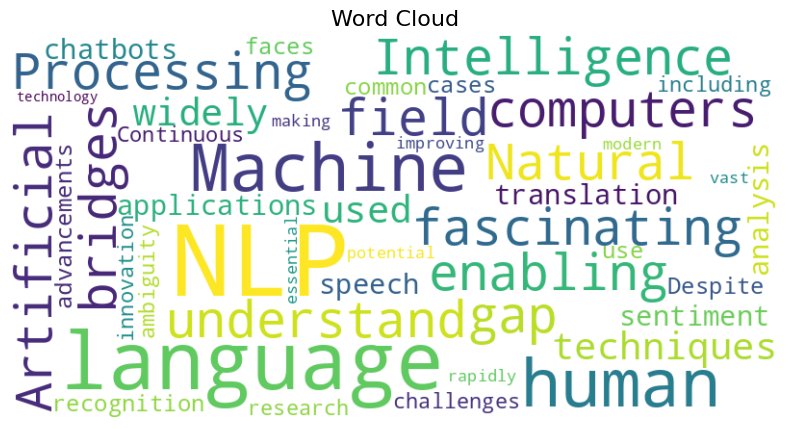

In [ ]:
#combine all text from the 'Text' column into a single
text_data = "".join(df['Text'].dropna())
#generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
#plot the word cloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
#plt.imshow: this function from matpltlib kibrary is used for display an image
#interpolation: determines how the image pixels are smoothed or blended when scaling
#bilinear: a specific interpolation method that averages the colors of the 4 nearest
plt.axis('off')#remove axes
plt.title("Word Cloud",fontsize=16)
plt.show()